# E24 · Hidden Markov models: marginalising a whole chain of discrete states

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | (A) every magnitude 7+ earthquake in the USGS ComCat catalogue, 1900-2024, as yearly counts - the modern version of the classic Poisson-HMM series; (B) GPS tracks of four elk released in Ontario (Morales et al. 2004, via `moveHMM`): step lengths, turning angles and distance to water |
| **You will learn** | The **forward algorithm** as a marginal likelihood, written with `pytensor.scan` and `logsumexp` · the same model from `pymc_extras` (`DiscreteMarkovChain` + `marginalize` + `recover`), checked against the hand-written one · **label switching** and the ordering constraint · recovering the states: **forward-backward** smoothing and **Viterbi** paths from posterior draws · stationary distribution and **dwell times** · forecast **pseudo-residuals** as the posterior predictive check · how many states? (a 3-state failure, LOO with the states integrated out, leave-future-out) · bivariate emissions over several sequences (padding and missing values for free) · **covariate-dependent transitions** |

E04 summed a *single* discrete changepoint out of a likelihood: 112 candidate years, one
`logsumexp`. E13 integrated out a *chain* of continuous states with the Kalman filter. A hidden
Markov model (HMM) sits between the two: one discrete state per time step, each depending on
the previous one. A series of length $T$ with $K$ states has $K^T$ possible state paths -
$2^{125}$ for the first dataset below - so summing over them one by one is out of the
question. The **forward algorithm** does the sum in $T K^2$ operations, by the same trick the
Kalman filter uses: carry forward the distribution of the current state given the data so
far. NUTS then sees a smooth likelihood of the continuous parameters only, and the states are
reconstructed afterwards. This is the discrete counterpart of E13, and the model to use when
a series looks like it switches between a few "regimes".

In [1]:
import gzip
import logging
import struct
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from pymc_extras.distributions import DiscreteMarkovChain
from pymc_extras.marginal import marginalize, recover
from scipy import stats
from scipy.special import expit, logsumexp

from pymc_challenges import data

warnings.filterwarnings("ignore", message="Numba will use object mode")
# Our likelihood is a Potential, so prior predictive sampling ignores it - intended here (section 2).
warnings.filterwarnings("ignore", message="The effect of Potentials")
logging.getLogger("pymc").setLevel(logging.WARNING)  # the helper below prints one line per fit

RANDOM_SEED = 2004
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
print(f"PyMC {pm.__version__}, PyTensor {pytensor.__version__}, ArviZ {az.__version__}")


def fit(model, label, **kw):
    """pm.sample with our defaults; prints time, divergences and the worst r_hat / ESS."""
    t0 = time.perf_counter()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    s = az.summary(idata, var_names=[v.name for v in model.free_RVs])
    print(f"{label}: {time.perf_counter() - t0:.0f} s, "
          f"divergences = {int(idata.sample_stats['diverging'].sum())}, "
          f"max r_hat = {s['r_hat'].max():.2f}, min ess_bulk = {int(s['ess_bulk'].min())}")
    return idata


def draws(idata, var, thin=1):
    """Posterior draws of one variable as a NumPy array with the (chain, draw) axes flattened."""
    da = idata.posterior[var].isel(draw=slice(None, None, thin))
    return da.values.reshape(-1, *da.shape[2:])

PyMC 6.3.2, PyTensor 3.3.2, ArviZ 1.3.0


# Part A · Is the Earth's seismicity switching between regimes?

## 1 · Question and data

Zucchini, MacDonald & Langrock's textbook on HMMs opens with the yearly number of major
(magnitude 7+) earthquakes worldwide from 1900 to 2006. That series is too variable for a
Poisson distribution and strongly autocorrelated: busy years come in runs. Their answer is a
Poisson HMM with two or three "activity regimes". Catalogues are revised, though. We rebuild
the series from today's USGS ComCat catalogue - whose 20th-century magnitudes have since been
recomputed (mostly as moment magnitudes, by the ISC-GEM project) - and extend it to 2024.

world_quakes_m7: Every magnitude 7+ earthquake worldwide, 1900-2024 (1591 events): time, location, depth, magnitude and magnitude type.
  source: USGS ComCat earthquake catalogue (FDSN event web service); pre-1976 events come from the ISC-GEM / Centennial catalogues. The classic Poisson-HMM series of Zucchini, MacDonald & Langrock (2016) is the 1900-2006 count of this catalogue as it stood then.
  url:    https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1900-01-01&endtime=2025-01-01&minmagnitude=7&orderby=time-asc
1591 events, 125 years; mean 12.7 per year, variance 17.4
magnitude types: {'mw': 989, 'mww': 202, 'mwc': 185, 'ms': 114}


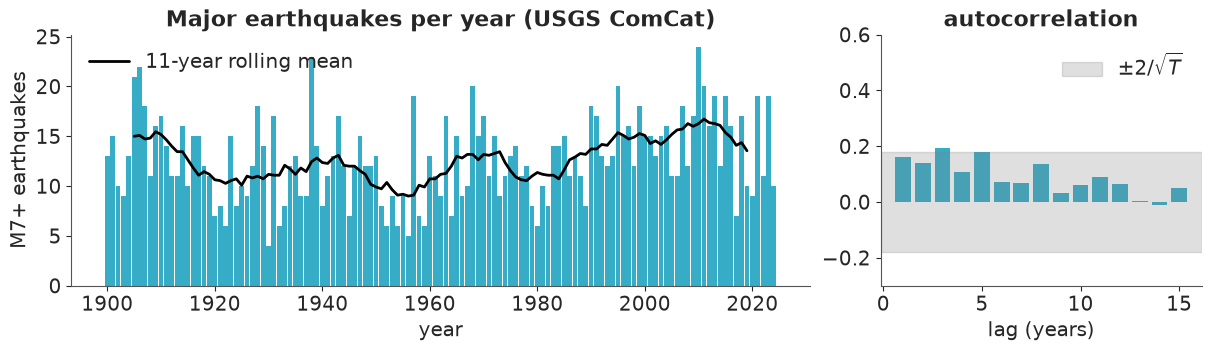

In [2]:
data.describe("world_quakes_m7")
quakes = data.load("world_quakes_m7")
years = np.arange(1900, 2025)
counts = quakes.time.dt.year.value_counts().reindex(years, fill_value=0).rename("quakes")
y = counts.to_numpy()
T = len(y)
print(f"{len(quakes)} events, {T} years; mean {y.mean():.1f} per year, variance {y.var(ddof=1):.1f}")
print("magnitude types:", quakes.magType.value_counts().head(4).to_dict())


def acf(x, max_lag):
    x = np.asarray(x, float) - np.mean(x)
    return np.array([1.0] + [np.sum(x[:-k] * x[k:]) / np.sum(x * x) for k in range(1, max_lag + 1)])


fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), width_ratios=[2.3, 1])
axes[0].bar(years, y, width=0.9, color="C0")
axes[0].plot(years, counts.rolling(11, center=True).mean(), color="k", lw=2, label="11-year rolling mean")
axes[0].set(xlabel="year", ylabel="M7+ earthquakes", title="Major earthquakes per year (USGS ComCat)")
axes[0].legend(loc="upper left")
axes[1].bar(np.arange(1, 16), acf(y, 15)[1:], color="C0")
axes[1].axhspan(-2 / np.sqrt(T), 2 / np.sqrt(T), color="grey", alpha=0.25, label=r"$\pm 2/\sqrt{T}$")
axes[1].set(xlabel="lag (years)", title="autocorrelation", ylim=(-0.3, 0.6))
axes[1].legend();

The first surprise is honest and worth stating up front: **the modern catalogue is much
tamer than the textbook series.** In the book (1900-2006) the mean is about 19 a year and the
variance well over twice that, with a lag-1 autocorrelation around 0.6. Here the mean is 12.7,
the variance only 17 (a Poisson variable would have 12.7), and every autocorrelation sits
around 0.1-0.2, just at the edge of the white-noise band - though it stays positive for twelve
lags in a row, which is what slowly switching regimes would produce. Recomputing old magnitudes moved
many events below 7 and removed much of the "regime" structure. Whether any is left is exactly
the kind of question a model with honest uncertainty should answer.

## 2 · The model and the forward algorithm

A $K$-state Poisson HMM:

$$
\begin{aligned}
s_1 &\sim \text{Categorical}(\delta), \qquad s_t \mid s_{t-1} \sim \text{Categorical}(\Gamma_{s_{t-1}, \cdot}) \\
y_t \mid s_t &\sim \text{Poisson}(\lambda_{s_t})
\end{aligned}
$$

$\Gamma$ is the transition matrix (row $i$: where you go from state $i$), $\delta$ the
distribution of the first state. The likelihood of the continuous parameters sums over all
state paths. Define the **forward variable** $\alpha_t(k) = p(y_1, \dots, y_t, s_t = k)$. It obeys

$$
\alpha_1(k) = \delta_k\, p(y_1 \mid k), \qquad
\alpha_t(k) = p(y_t \mid k) \sum_j \alpha_{t-1}(j)\, \Gamma_{jk}, \qquad
p(y_{1:T}) = \sum_k \alpha_T(k).
$$

The $\alpha$'s underflow after a few dozen steps (each is a product of $t$ probabilities), so
everything is done on the log scale, where the sum over $j$ is a `logsumexp`. The loop over
time is a `pytensor.scan`: `sequences` are sliced along their first axis (one emission row
per step), `outputs_info` is the carried state ($\log\alpha_{t-1}$), and `non_sequences` are
passed unchanged. The function below works for any number of leading "batch" axes (several
sequences at once - we need that in Part B) and, optionally, a different transition matrix
at every step.

In [3]:
def hmm_loglik(log_emis, log_Gamma, log_delta, time_varying=False):
    """log p(y_1..T) with the hidden states summed out (forward algorithm on the log scale).

    log_emis:  (T, ..., K)  log p(y_t | s_t = k)
    log_Gamma: (..., K, K), or (T-1, ..., K, K) with time_varying=True: row = from, column = to
    log_delta: (..., K)     log p(s_1 = k)
    returns:   (...)        one log-likelihood per sequence
    """
    def step(*args):
        if time_varying:
            log_e_t, log_G_t, log_alpha = args
        else:
            log_e_t, log_alpha, log_G_t = args
        # log alpha_t(k) = log p(y_t | k) + logsumexp_j [log alpha_{t-1}(j) + log Gamma_jk]
        return log_e_t + pt.logsumexp(log_alpha[..., :, None] + log_G_t, axis=-2)

    log_alpha_1 = log_delta + log_emis[0]
    log_alpha = pytensor.scan(
        step,
        sequences=[log_emis[1:], log_Gamma] if time_varying else [log_emis[1:]],
        outputs_info=[log_alpha_1],
        non_sequences=[] if time_varying else [log_Gamma],
        return_updates=False,
    )
    return pt.logsumexp(log_alpha[-1], axis=-1)


def poisson_hmm(K, counts, ordered=True, stay=4.0):
    """K-state Poisson HMM with the states marginalised by hmm_loglik."""
    with pm.Model(coords={"state": np.arange(K), "to": np.arange(K), "year": years[: len(counts)]}) as model:
        transform = {"transform": pm.distributions.transforms.ordered} if ordered else {}
        lam = pm.Gamma("lam", alpha=3, beta=0.2, dims="state", **transform)
        Gamma = pm.Dirichlet("Gamma", a=np.ones((K, K)) + stay * np.eye(K), dims=("state", "to"))
        delta = pm.Dirichlet("delta", a=np.ones(K), dims="state")
        log_emis = pm.logp(pm.Poisson.dist(lam), counts[:, None])  # (T, K)
        pm.Potential("hmm_loglik", hmm_loglik(log_emis, pt.log(Gamma), pt.log(delta)))
    return model

### Priors

- $\lambda_k \sim \text{Gamma}(3, 0.2)$: mean 15 a year, 94% of the mass between about 3 and
  33 - wide on the scale of "tens of big earthquakes a year".
- Each row of $\Gamma$ is Dirichlet with weight $1 + 4$ on staying and 1 on each move. For
  $K=2$ that is a Beta(5, 1) prior on the probability of staying: mean 0.83, i.e. regimes that
  last about six years on average, but it keeps plenty of mass below 0.5. Regimes that flip
  every year would be indistinguishable from a plain mixture, so a mild preference for
  persistence is what "regime" means. We will check what this prior does in section 7.
- $\delta \sim$ Dirichlet(1, ..., 1): the first year's state is informed by one observation
  only; its posterior will stay close to this prior.

The `Potential` is invisible to `pm.sample_prior_predictive`, which therefore gives us draws
of the parameters; the series we simulate ourselves (a dozen lines of NumPy that we reuse for
posterior predictive checks). Note that prior draws ignore the `ordered` transform (see the
Gotchas in AUTHORING.md), so we sort them.

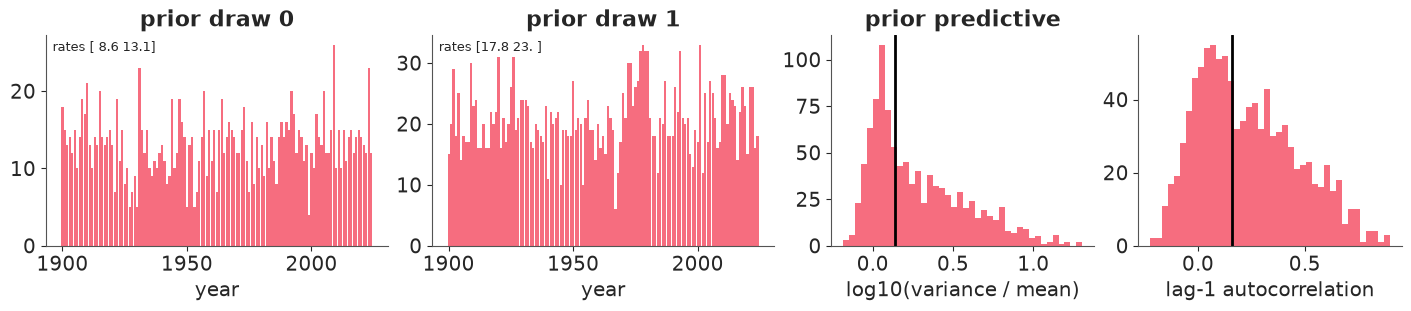

In [4]:
def simulate_hmm(lam, Gamma, delta, T, rng):
    """One Poisson-HMM series per parameter draw. lam (S, K), Gamma (S, K, K), delta (S, K)."""
    S, K = lam.shape
    rows = np.arange(S)
    pick = lambda p: np.minimum((rng.random(S)[:, None] > np.cumsum(p, axis=1)).sum(1), K - 1)
    s = np.empty((S, T), dtype=int)
    s[:, 0] = pick(delta)
    for t in range(1, T):
        s[:, t] = pick(Gamma[rows, s[:, t - 1]])
    return rng.poisson(lam[rows[:, None], s]), s


def dispersion_and_acf1(sims):
    """Variance/mean ratio and lag-1 autocorrelation of each simulated series (rows)."""
    centred = sims - sims.mean(1, keepdims=True)
    ratio = sims.var(1, ddof=1) / np.maximum(sims.mean(1), 1e-9)
    ac1 = (centred[:, 1:] * centred[:, :-1]).sum(1) / np.maximum((centred**2).sum(1), 1e-9)
    return ratio, ac1


with poisson_hmm(2, y):
    prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
prior_draw = lambda v: prior.prior[v].values.reshape(-1, *prior.prior[v].shape[2:])
prior_lam = np.sort(prior_draw("lam"), axis=1)  # prior draws ignore the ordered transform
prior_sims, _ = simulate_hmm(prior_lam, prior_draw("Gamma"), prior_draw("delta"), T, rng)
obs_ratio, obs_ac1 = dispersion_and_acf1(y[None])

fig, axes = plt.subplots(1, 4, figsize=(14, 3), width_ratios=[1.3, 1.3, 1, 1])
for ax, i in zip(axes[:2], [0, 1]):
    ax.bar(years, prior_sims[i], width=0.9, color="C1")
    ax.set(title=f"prior draw {i}", xlabel="year")
    ax.text(0.02, 0.97, f"rates {prior_lam[i].round(1)}", transform=ax.transAxes, va="top", fontsize=9)
ratio, ac1 = dispersion_and_acf1(prior_sims)
axes[2].hist(np.log10(ratio), bins=40, color="C1")
axes[2].axvline(np.log10(obs_ratio[0]), color="k", lw=2)
axes[2].set(xlabel="log10(variance / mean)", title="prior predictive")
axes[3].hist(ac1, bins=40, color="C1")
axes[3].axvline(obs_ac1[0], color="k", lw=2)
axes[3].set(xlabel="lag-1 autocorrelation");

Prior simulations switch between two rates at a believable scale, from nearly equal to far
apart; the observed dispersion and
autocorrelation (black lines) are well inside what the prior allows, and so is "no regimes
at all" (ratio near 1, autocorrelation near 0).

## 3 · A failure first: label switching

Nothing in the likelihood says which state is "state 0". Swap the two rates, swap the rows
and columns of $\Gamma$ and the entries of $\delta$, and the likelihood is identical, so the
posterior has $K!$ identical modes. With unconstrained rates, each chain picks one:

In [5]:
unordered_idata = fit(poisson_hmm(2, y, ordered=False), "2 states, unordered rates")
print(unordered_idata.posterior["lam"].mean("draw").round(1).to_pandas())

2 states, unordered rates: 4 s, divergences = 0, max r_hat = 1.35, min ess_bulk = 9
state     0     1
chain            
0      13.0  12.6
1      13.2  12.5
2      14.8  10.9
3      14.8  10.9


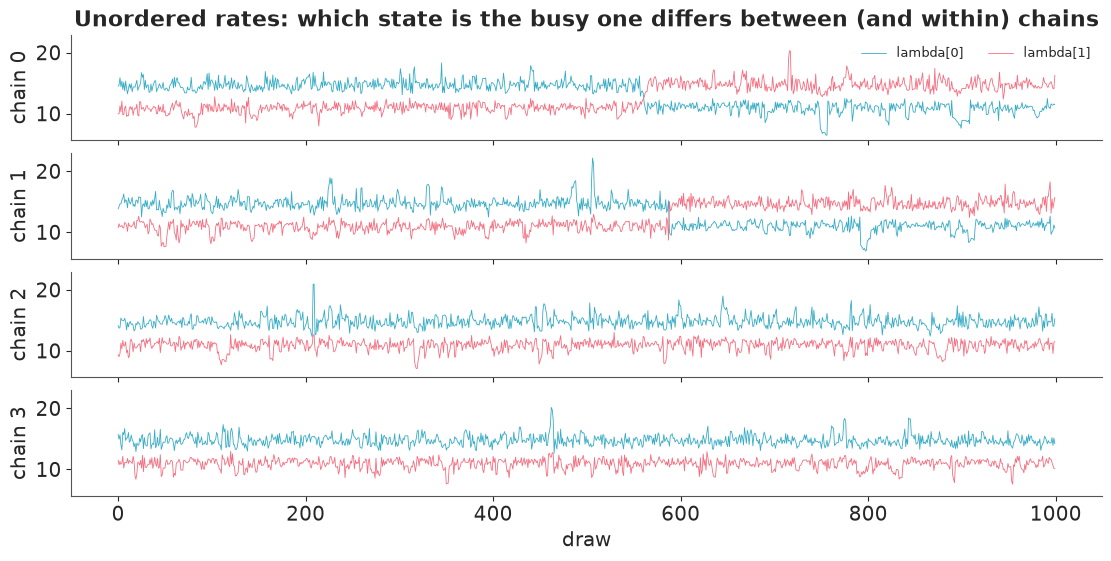

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(11, 5.5), sharex=True, sharey=True)
for ax, c in zip(axes, unordered_idata.posterior.chain.values):
    for k in [0, 1]:
        ax.plot(unordered_idata.posterior["lam"].sel(chain=c, state=k), color=f"C{k}", lw=0.6,
                label=f"lambda[{k}]")
    ax.set_ylabel(f"chain {c}")
axes[0].set_title("Unordered rates: which state is the busy one differs between (and within) chains")
axes[0].legend(ncols=2, fontsize=9, loc="upper right")
axes[-1].set_xlabel("draw");

The two rates are the same two numbers in every chain - about 11 and 15 - but which of them
is called `lam[0]` differs between chains, and a chain can even swap labels mid-run when the
sampler crosses the region where the two rates are close. (nutpie is not bit-reproducible, so
which chains swap changes from run to run; `r_hat` for `lam` came out between about 1.3 and 1.5,
with single-digit ESS, in every run we tried.) Nothing is wrong with any individual chain's
picture of the physics - the *labels* are unidentified, and r_hat correctly reports that the
chains did not sample the same distribution. (The transition probabilities look fine only
because this $\Gamma$ happens to be nearly symmetric under the swap.)

**The fix** is to break the symmetry: require $\lambda_0 < \lambda_1$ with the `ordered`
transform, which leaves exactly one of the $K!$ modes. Ordered variables need starting values
that respect the order; as noted in AUTHORING.md we pass them to `pm.sample(initvals=...)`
rather than as `initval=` on the variable.

In [7]:
INIT2 = {"lam": np.array([10.0, 15.0])}
hmm2 = poisson_hmm(2, y)
hmm2_idata = fit(hmm2, "2 states, ordered rates", initvals=INIT2)
az.summary(hmm2_idata, var_names=["lam", "Gamma", "delta"], ci_kind="hdi", ci_prob=0.94, round_to=2)

2 states, ordered rates: 4 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 969


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
lam[0],10.85,0.89,9.11,12.33,969.94,632.45,1.0,0.03,0.05
lam[1],14.77,0.91,13.08,16.31,1854.33,1783.11,1.0,0.02,0.03
"Gamma[0, 0]",0.89,0.09,0.71,1.00,1320.36,1347.66,1.0,0.00,0.00
"Gamma[0, 1]",0.11,0.09,0.00,0.29,1320.36,1347.66,1.0,0.00,0.00
"Gamma[1, 0]",0.11,0.08,0.01,0.26,2344.78,2100.00,1.0,0.00,0.00
"Gamma[1, 1]",0.89,0.08,0.74,0.99,2344.78,2100.00,1.0,0.00,0.00
delta[0],0.46,0.28,0.00,0.92,3993.58,2468.71,1.0,0.00,0.00
delta[1],0.54,0.28,0.08,1.00,3993.58,2468.71,1.0,0.00,0.00


All `r_hat` at 1.00, no divergences. A quiet regime of about 11 M7+ earthquakes a year and a
busy one of about 15, each persisting with a probability of about 0.89 per year. The
posterior of $\delta$ is the Dirichlet(1, 1) prior shifted a little, as expected from one
observation.

(An ordering constraint is not always the right cure. It works when the states differ
clearly in the ordered parameter; if two rates overlap, the constraint just cuts a
multimodal posterior in an arbitrary place. Section 7 shows that.)

## 4 · The same model from `pymc_extras`

`pymc_extras` has a `DiscreteMarkovChain` distribution for the state path, so the HMM can be
written *generatively* - states and all - and `marginalize` rewrites it into a model without
the states (it recognises the chain and uses a forward algorithm), exactly as it did for the
changepoint in E04.

In [8]:
with pm.Model(coords={"state": np.arange(2), "to": np.arange(2), "year": years}) as generative_hmm:
    lam = pm.Gamma("lam", alpha=3, beta=0.2, dims="state", transform=pm.distributions.transforms.ordered)
    Gamma = pm.Dirichlet("Gamma", a=np.ones((2, 2)) + 4 * np.eye(2), dims=("state", "to"))
    delta = pm.Dirichlet("delta", a=np.ones(2), dims="state")
    regime = DiscreteMarkovChain("regime", P=Gamma, init_dist=pm.Categorical.dist(p=delta), dims="year")
    pm.Poisson("quakes", lam[regime], observed=y, dims="year")

marginal_hmm = marginalize(generative_hmm, ["regime"])

# Compare the two log-densities at one point. The default initial point puts both rates at 15,
# where `ordered` gives -inf, so move them apart - on the unconstrained scale, via the model's
# own transform (for a positive variable PyMC chains log + ordered: the value is "lam_chain__").
point = hmm2.initial_point()
lam_rv = hmm2["lam"]
point[hmm2.rvs_to_values[lam_rv].name] = hmm2.rvs_to_transforms[lam_rv].forward(
    pt.as_tensor([9.0, 16.0]), *lam_rv.owner.inputs).eval()
point["Gamma_simplex__"] = point["Gamma_simplex__"] + np.array([[0.3], [-0.5]])
print("log-density at the same point: hand-written", round(float(hmm2.compile_logp()(point)), 6),
      " pymc_extras", round(float(marginal_hmm.compile_logp()(point)), 6))

extras_idata = fit(marginal_hmm, "pymc_extras marginalize", initvals=INIT2)
t0 = time.perf_counter()
recover(extras_idata, model=marginal_hmm, random_seed=RANDOM_SEED)
print(f"recover: {time.perf_counter() - t0:.1f} s; new posterior variable 'regime' with shape",
      dict(extras_idata.posterior["regime"].sizes))
az.summary(extras_idata, var_names=["lam", "Gamma"], ci_kind="hdi", ci_prob=0.94, round_to=2)

log-density at the same point: hand-written -364.95362  pymc_extras -364.95362


pymc_extras marginalize: 5 s, divergences = 0, max r_hat = 1.01, min ess_bulk = 892


recover: 0.6 s; new posterior variable 'regime' with shape {'chain': 4, 'draw': 1000, 'year': 125}


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
lam[0],10.88,0.85,9.26,12.30,893.00,653.32,1.01,0.04,0.08
lam[1],14.78,1.09,13.24,16.42,2306.79,2537.09,1.00,0.04,0.19
"Gamma[0, 0]",0.89,0.10,0.71,1.00,1083.02,899.00,1.00,0.00,0.01
"Gamma[0, 1]",0.11,0.10,0.00,0.29,1083.02,882.44,1.00,0.00,0.01
"Gamma[1, 0]",0.11,0.08,0.00,0.27,2687.23,2189.54,1.00,0.00,0.00
"Gamma[1, 1]",0.89,0.08,0.73,1.00,2687.23,2189.54,1.00,0.00,0.00


The two log-densities agree to six decimals, so the two models are the same distribution -
which is the check that matters for the hand-written scan. Their posteriors agree within Monte
Carlo error. (The draws differ, unlike E04 where both versions produced identical draws: the
two graphs are different, so nutpie's random initialisation differs.) Both fits take a few
seconds. `recover` added one sampled state path per posterior draw, which gives us the states
for free.

Why write the scan by hand at all? Because it is the version you can bend: several sequences
of different lengths, missing observations, two emission distributions at once, transition
probabilities that depend on covariates - all of which Part B needs - are a line each in the
hand-written likelihood. (`DiscreteMarkovChain` does accept time-varying $P$ via
`time_varying_P=True`.)

## 5 · Recovering the states

Sampled paths from `recover` are one option. The exact alternative, as in E04, is to compute
the state probabilities *given each draw of the parameters* and average them
(Rao-Blackwellisation). The **backward variable** $\beta_t(k) = p(y_{t+1:T} \mid s_t = k)$
obeys a mirror-image recursion, and

$$
p(s_t = k \mid y_{1:T}, \theta) = \frac{\alpha_t(k)\, \beta_t(k)}{p(y_{1:T} \mid \theta)}.
$$

This is **forward-backward smoothing**: the discrete counterpart of the Kalman smoother in
E13. We run it in NumPy on all posterior draws at once (loop over time, vectorised over
draws), because the per-draw results are needed only after sampling. Separately, the
**Viterbi** algorithm finds the single most probable *path* $\arg\max_{s_{1:T}} p(s_{1:T} \mid
y, \theta)$ - replace the sum in the forward recursion by a max and trace back. Smoothed
probabilities answer "which state was year $t$ in?"; Viterbi answers "what is the best
joint story?". They usually agree, but not always.

In [9]:
def forward_backward(log_emis, log_Gamma, log_delta):
    """Log forward and backward variables for every draw.

    log_emis (S, T, ..., K); log_Gamma (S, T-1, ..., K, K) (broadcast views are fine); log_delta (S, ..., K).
    """
    S, T = log_emis.shape[:2]
    log_a = np.empty_like(log_emis)
    log_b = np.zeros_like(log_emis)
    log_a[:, 0] = log_delta + log_emis[:, 0]
    for t in range(1, T):
        log_a[:, t] = log_emis[:, t] + logsumexp(log_a[:, t - 1][..., :, None] + log_Gamma[:, t - 1], axis=-2)
    for t in range(T - 2, -1, -1):
        log_b[:, t] = logsumexp(log_Gamma[:, t] + (log_emis[:, t + 1] + log_b[:, t + 1])[..., None, :], axis=-1)
    return log_a, log_b


def viterbi(log_emis, log_Gamma, log_delta):
    """Most probable state path for every draw (same shapes as forward_backward)."""
    S, T = log_emis.shape[:2]
    score = log_delta + log_emis[:, 0]
    back = np.empty(log_emis.shape, dtype=int)
    for t in range(1, T):
        cand = score[..., :, None] + log_Gamma[:, t - 1]  # (..., from, to)
        back[:, t] = cand.argmax(axis=-2)
        score = log_emis[:, t] + cand.max(axis=-2)
    path = np.empty(log_emis.shape[:-1], dtype=int)
    path[:, -1] = score.argmax(-1)
    for t in range(T - 2, -1, -1):
        path[:, t] = np.take_along_axis(back[:, t + 1], path[:, t + 1][..., None], axis=-1)[..., 0]
    return path


def poisson_hmm_arrays(idata, counts, thin=1):
    lam, Gamma, delta = (draws(idata, v, thin) for v in ["lam", "Gamma", "delta"])
    log_emis = stats.poisson.logpmf(counts[None, :, None], lam[:, None, :])  # (S, T, K)
    log_G = np.broadcast_to(np.log(Gamma)[:, None], (len(lam), len(counts) - 1, *Gamma.shape[1:]))
    return lam, log_emis, log_G, np.log(delta)


lam2, log_emis2, log_G2, log_delta2 = poisson_hmm_arrays(hmm2_idata, y)
G2, delta2 = draws(hmm2_idata, "Gamma"), draws(hmm2_idata, "delta")
log_a2, log_b2 = forward_backward(log_emis2, log_G2, log_delta2)
log_lik2 = logsumexp(log_a2[:, -1], axis=-1)  # (S,) = p(y | theta), same as the Potential
p_busy = np.exp(log_a2 + log_b2 - log_lik2[:, None, None])[..., 1]  # (S, T): P(busy regime | y, theta)
paths2 = viterbi(log_emis2, log_G2, log_delta2)
print("forward-backward on 4000 draws done; P(busy) from recover() vs forward-backward, max difference:",
      np.abs(extras_idata.posterior["regime"].mean(("chain", "draw")).values - p_busy.mean(0)).max().round(3))

forward-backward on 4000 draws done; P(busy) from recover() vs forward-backward, max difference: 0.011


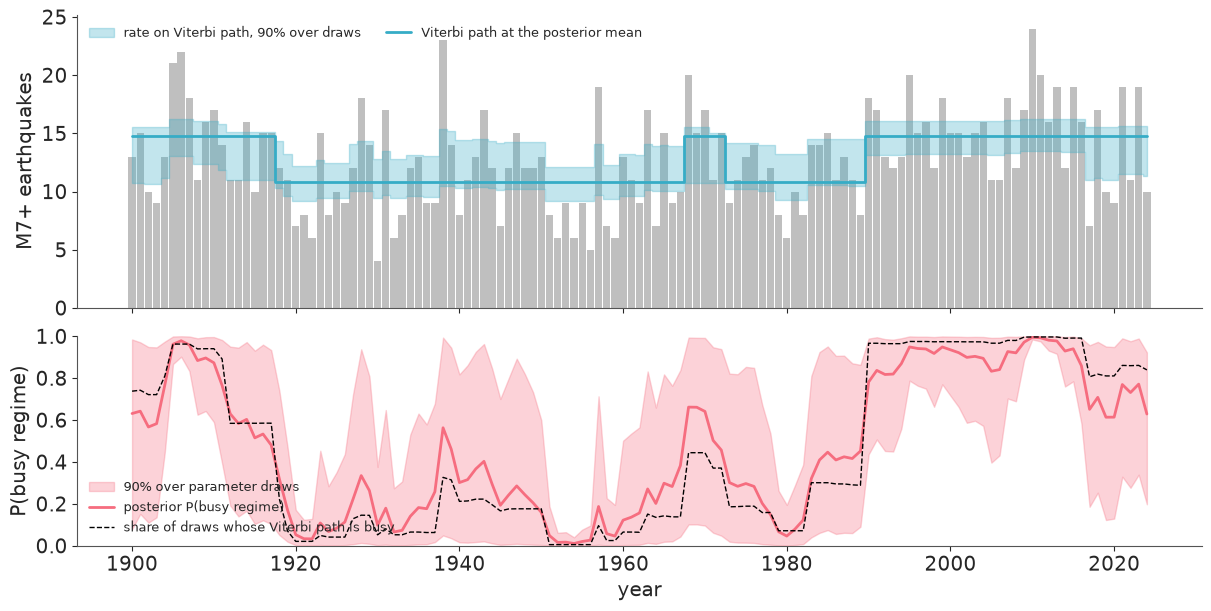

In [10]:
rate_path = lam2[np.arange(len(lam2))[:, None], paths2]  # the rate along each draw's Viterbi path
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, height_ratios=[1.4, 1])
axes[0].bar(years, y, width=0.9, color="grey", alpha=0.5)
lo, hi = np.quantile(rate_path, [0.05, 0.95], axis=0)
axes[0].fill_between(years, lo, hi, color="C0", alpha=0.3, step="mid", label="rate on Viterbi path, 90% over draws")
lam_mean = lam2.mean(0)  # Viterbi once more, at the posterior-mean parameters (a single "draw")
path_at_mean = viterbi(stats.poisson.logpmf(y[None, :, None], lam_mean[None, None, :]),
                       np.log(G2.mean(0))[None, None].repeat(T - 1, axis=1), np.log(delta2.mean(0))[None])[0]
axes[0].step(years, lam_mean[path_at_mean], where="mid", color="C0", lw=2, label="Viterbi path at the posterior mean")
axes[0].set(ylabel="M7+ earthquakes")
axes[0].legend(loc="upper left", fontsize=9, ncols=2)
lo, hi = np.quantile(p_busy, [0.05, 0.95], axis=0)
axes[1].fill_between(years, lo, hi, color="C1", alpha=0.3, label="90% over parameter draws")
axes[1].plot(years, p_busy.mean(0), color="C1", lw=2, label="posterior P(busy regime)")
axes[1].plot(years, (paths2 == 1).mean(0), color="k", lw=1, ls="--", label="share of draws whose Viterbi path is busy")
axes[1].set(xlabel="year", ylabel="P(busy regime)", ylim=(0, 1))
axes[1].legend(loc="lower left", fontsize=9);

The smoothed probabilities from forward-backward and the frequencies of `recover`'s sampled
paths agree up to Monte Carlo noise (maximum difference printed above). The story they tell:
a busy stretch around 1905-1915, brief bumps in the late 1930s and around 1970, and a long
busy period from about 1990 to the mid-2010s, with quieter decades in between (the early
1950s are the most confidently quiet years). But look at the band: for most years the
probability of the busy regime ranges over half the unit interval across parameter draws.
When the two rates are only four quakes a year apart and a Poisson count has a standard
deviation of about 3.5, one year cannot tell them apart; the regime assignment is driven by
*runs* of years. The share of draws whose Viterbi path is busy (dashed) is pushed further
towards 0 or 1 than the smoothed probability: Viterbi commits every year to one state, and
the most probable *path* can disagree with the most probable state of a single year.

### Stationary distribution and dwell times

Two summaries of $\Gamma$ are more interpretable than its entries. The **stationary
distribution** $\pi$ solves $\pi\Gamma = \pi$: the long-run share of time in each regime. The
time spent in state $k$ once entered is geometric with mean **dwell time**
$1 / (1 - \Gamma_{kk})$. Both are functions of the parameters, so they get posteriors for free.

quiet: long-run share 0.52 (94% HDI [0.19 0.89]), dwell time median 12 years (94% HDI [ 2. 60.])
busy : long-run share 0.48 (94% HDI [0.11 0.81]), dwell time median 11 years (94% HDI [ 2. 43.])


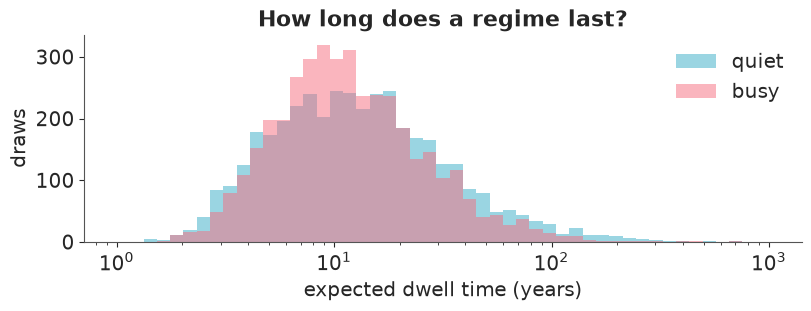

In [11]:
def stationary(Gamma):
    """Stationary distribution of each (K, K) transition matrix in a stack (..., K, K)."""
    K = Gamma.shape[-1]
    A = np.swapaxes(Gamma, -1, -2) - np.eye(K)
    A[..., -1, :] = 1.0  # replace one equation by sum(pi) = 1
    b = np.zeros(Gamma.shape[:-1])
    b[..., -1] = 1.0
    return np.linalg.solve(A, b[..., None])[..., 0]


pi2 = stationary(G2)
dwell2 = 1 / (1 - np.diagonal(G2, axis1=1, axis2=2))
for k, name in enumerate(["quiet", "busy"]):
    print(f"{name:5s}: long-run share {pi2[:, k].mean():.2f} (94% HDI {az.hdi(pi2[:, k], prob=0.94).round(2)}), "
          f"dwell time median {np.median(dwell2[:, k]):.0f} years (94% HDI {az.hdi(dwell2[:, k], prob=0.94).round(0)})")

fig, ax = plt.subplots(figsize=(8, 3))
bins = np.geomspace(1, 1000, 50)
for k, name in enumerate(["quiet", "busy"]):
    ax.hist(dwell2[:, k], bins=bins, alpha=0.5, color=f"C{k}", label=name)
ax.set(xscale="log", xlabel="expected dwell time (years)", ylabel="draws", title="How long does a regime last?")
ax.legend();

About half the time in each regime, and a typical regime lasts roughly a decade - but the
dwell-time posteriors are wide and right-skewed: a few years to several decades are all
compatible with 125 years of data containing only a handful of switches. You cannot learn
much about persistence from few transitions, which is why the prior on $\Gamma$ matters
(section 7).

## 6 · Posterior predictive checks: pseudo-residuals

For an HMM the natural residual is a **forecast pseudo-residual** (Zucchini et al., ch. 6).
Take the one-step-ahead predictive distribution $F_t(y) = P(Y_t \le y \mid y_{1:t-1})$, a
mixture over the predicted state, and transform the observation: if the model is right,
$u_t = F_t(y_t)$ is uniform and $z_t = \Phi^{-1}(u_t)$ is standard normal and *independent
over time*. For counts, $F_t$ jumps, so we use the **mid-pseudo-residual**
$\Phi^{-1}\big((F_t(y_t - 1) + F_t(y_t)) / 2\big)$. The Bayesian version averages $F_t$ over
posterior draws (the posterior predictive CDF). The predicted state distribution comes from
the forward variables: $p(s_t \mid y_{1:t-1}) \propto \sum_j \alpha_{t-1}(j)\Gamma_{jk}$.

The baseline is the model without regimes, a single Poisson rate, whose "forecast" ignores the
past.

1 state (plain Poisson): 0 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 1699


1 state: sd 1.15, lag-1..3 autocorrelation [0.16 0.16 0.2 ]
2-state HMM: sd 1.01, lag-1..3 autocorrelation [-0.02  0.02  0.1 ]


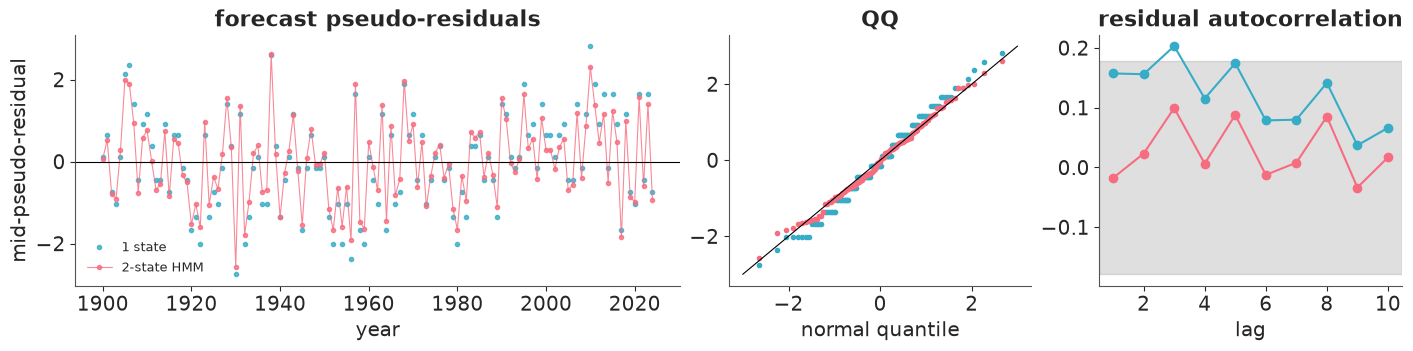

In [12]:
def predicted_state_logprob(log_a, log_Gamma, log_delta):
    """log p(s_t = k, y_{1:t-1}) for every t (unnormalised one-step-ahead state probabilities)."""
    pred = np.empty_like(log_a)
    pred[:, 0] = log_delta
    pred[:, 1:] = logsumexp(log_a[:, :-1][..., :, None] + log_Gamma, axis=-2)
    return pred


def mid_pseudo_residuals(weights, lam, counts):
    """weights (S, T, K) one-step-ahead state probabilities, lam (S, K)."""
    cdf = lambda v: (weights * stats.poisson.cdf(v[None, :, None], lam[:, None, :])).sum(-1).mean(0)
    return stats.norm.ppf((cdf(counts - 1) + cdf(counts)) / 2)


with pm.Model() as poisson1:
    rate = pm.Gamma("lam", alpha=3, beta=0.2)
    pm.Poisson("quakes", rate, observed=y)
poisson1_idata = fit(poisson1, "1 state (plain Poisson)")
lam1 = draws(poisson1_idata, "lam")[:, None]

pred2 = predicted_state_logprob(log_a2, log_G2, log_delta2)
w2 = np.exp(pred2 - logsumexp(pred2, axis=-1, keepdims=True))
z = {"1 state": mid_pseudo_residuals(np.ones((len(lam1), T, 1)), lam1, y),
     "2-state HMM": mid_pseudo_residuals(w2, lam2, y)}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), width_ratios=[2, 1, 1])
for i, (name, zz) in enumerate(z.items()):
    axes[0].plot(years, zz, "o-" if i else "o", ms=3, lw=0.8, color=f"C{i}", alpha=0.8, label=name)
    q = stats.norm.ppf((np.arange(T) + 0.5) / T)
    axes[1].plot(q, np.sort(zz), "o", ms=3, color=f"C{i}", label=name)
    axes[2].plot(np.arange(1, 11), acf(zz, 10)[1:], "o-", color=f"C{i}", label=name)
    print(f"{name}: sd {zz.std():.2f}, lag-1..3 autocorrelation {acf(zz, 3)[1:].round(2)}")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(xlabel="year", ylabel="mid-pseudo-residual", title="forecast pseudo-residuals")
axes[1].plot([-3, 3], [-3, 3], color="k", lw=0.8)
axes[1].set(xlabel="normal quantile", title="QQ")
axes[2].axhspan(-2 / np.sqrt(T), 2 / np.sqrt(T), color="grey", alpha=0.25)
axes[2].set(xlabel="lag", title="residual autocorrelation")
axes[0].legend(fontsize=9);

Both sets of residuals are roughly normal: the marginal distribution was never the problem.
The difference is in the autocorrelation panel: the plain Poisson residuals inherit the
series' positive autocorrelation at every lag, while the HMM's one-step-ahead forecasts
absorb most of it - what is left sits inside the white-noise band. That is what the hidden
state is *for*: carrying information from recent years into the forecast.

The same point from simulated data: replicate the whole series from each posterior draw and
compare the statistics a regime model must reproduce.

1 state: P(sim >= observed): variance/mean 0.007, lag-1 autocorrelation 0.035
2-state HMM: P(sim >= observed): variance/mean 0.266, lag-1 autocorrelation 0.393


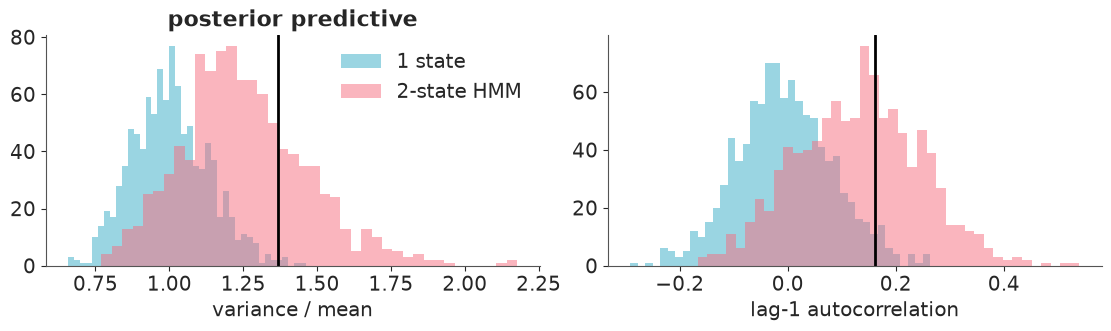

In [13]:
sub = rng.choice(len(lam2), 1000, replace=False)
sims2, _ = simulate_hmm(lam2[sub], G2[sub], delta2[sub], T, rng)
sims1 = rng.poisson(np.broadcast_to(lam1[sub], (1000, T)))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for i, (name, sims) in enumerate({"1 state": sims1, "2-state HMM": sims2}.items()):
    ratio, ac1 = dispersion_and_acf1(sims)
    axes[0].hist(ratio, bins=40, alpha=0.5, color=f"C{i}", label=name)
    axes[1].hist(ac1, bins=40, alpha=0.5, color=f"C{i}", label=name)
    print(f"{name}: P(sim >= observed): variance/mean {np.mean(ratio >= obs_ratio[0]):.3f}, "
          f"lag-1 autocorrelation {np.mean(ac1 >= obs_ac1[0]):.3f}")
axes[0].axvline(obs_ratio[0], color="k", lw=2)
axes[1].axvline(obs_ac1[0], color="k", lw=2)
axes[0].set(xlabel="variance / mean", title="posterior predictive")
axes[1].set(xlabel="lag-1 autocorrelation")
axes[0].legend();

The plain Poisson model essentially never produces the observed dispersion (and rarely the
autocorrelation); the HMM reproduces both comfortably. So the data do contain *something*
beyond Poisson noise. Whether "two regimes" is the best description of it is the next question.

## 7 · How many states?

### A second failure: more states than the data support

Zucchini et al. preferred three states for the old catalogue. Here, three and four:

In [14]:
hmm3_idata = fit(poisson_hmm(3, y), "3 states", initvals={"lam": np.array([9.0, 12.0, 16.0])})
hmm4_idata = fit(poisson_hmm(4, y), "4 states", initvals={"lam": np.array([9.0, 11.5, 14.0, 16.0])})
az.summary(hmm4_idata, var_names=["lam"], ci_kind="hdi", ci_prob=0.94, round_to=2)

3 states: 6 s, divergences = 5, max r_hat = 1.01, min ess_bulk = 759


4 states: 7 s, divergences = 32, max r_hat = 1.01, min ess_bulk = 773


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
lam[0],9.55,1.19,7.25,11.62,773.75,662.29,1.01,0.05,0.04
lam[1],11.74,1.23,9.39,14.05,1601.16,1979.12,1.00,0.03,0.02
lam[2],13.68,1.22,11.44,15.95,2361.67,2475.77,1.00,0.03,0.02
lam[3],15.96,1.72,13.40,18.88,2312.82,2452.99,1.00,0.03,0.06


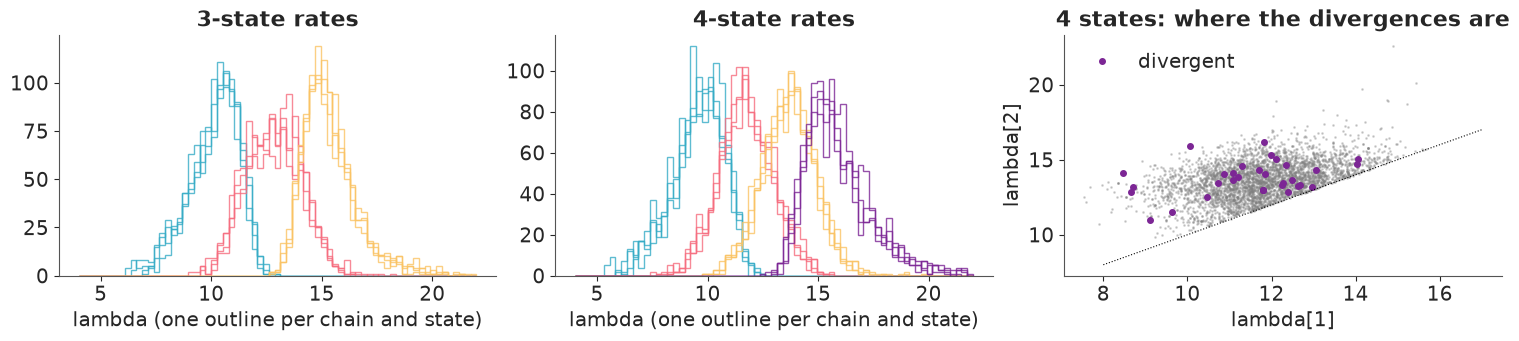

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.3))
for ax, idata, K in [(axes[0], hmm3_idata, 3), (axes[1], hmm4_idata, 4)]:
    for k in range(K):
        for c in idata.posterior.chain.values:
            ax.hist(idata.posterior["lam"].sel(chain=c, state=k).values, bins=np.linspace(4, 22, 70),
                    histtype="step", color=f"C{k}", alpha=0.8)
    ax.set(xlabel="lambda (one outline per chain and state)", title=f"{K}-state rates")
div = hmm4_idata.sample_stats["diverging"].values.ravel()
l1, l2 = (hmm4_idata.posterior["lam"].sel(state=k).values.ravel() for k in (1, 2))
axes[2].plot(l1[~div], l2[~div], ".", ms=2, alpha=0.3, color="grey")
axes[2].plot(l1[div], l2[div], "o", ms=4, color="C3", label="divergent")
axes[2].plot([8, 17], [8, 17], color="k", lw=0.8, ls=":")
axes[2].set(xlabel="lambda[1]", ylabel="lambda[2]", title="4 states: where the divergences are")
axes[2].legend();

Nothing as dramatic as label switching, but the symptoms are all there. Divergences appear
(a handful for three states, dozens for four; across the seeds we tried, 8-22 and 40-55), and
the rate posteriors of neighbouring states overlap over most of their mass: the "extra"
states are not distinct regimes but slices of the same two. Adjacent rates sit against the
ordering boundary $\lambda_1 < \lambda_2$ (dotted diagonal), and when a state is rarely
visited its rate is pinned only by the prior - ridges and funnels that NUTS reports as
divergences. This is what "too many states" looks like, and it is a *modelling* result, not a
sampler setting to tune: raising `target_accept` would hide the divergences without making the
extra states real.

### Comparing models when the observations are not exchangeable

PSIS-LOO needs $\log p(y_t \mid \theta)$ for each observation, but in an HMM the $y_t$ are not
independent given $\theta$ - they are linked through the hidden chain. Two honest options:

1. **LOO with the states integrated out** (the E04 trick). Leaving out $y_t$ means replacing
   its emission probability by 1:
   $p(y_t \mid y_{-t}, \theta) = p(y_{1:T} \mid \theta) / p(y_{-t} \mid \theta)$, and
   $p(y_{-t} \mid \theta) = \sum_k p(s_t = k, y_{1:t-1})\,\beta_t(k)$ - the same forward and
   backward variables again, no refit. This measures how well a year is predicted from *both*
   its past and its future: interpolation.
2. **Leave-future-out** (LFO). Forecasting is the harder and often the relevant task: fit on
   1900-1989 only, then score each later year by its one-step-ahead density
   $p(y_t \mid y_{1:t-1})$, running the filter on through the test years. (Here the parameters
   stay at their 1900-1989 posterior; exact LFO would refit every year, PSIS-LFO of Bürkner,
   Gabry & Vehtari (2020) approximates that.)

The competitors: one Poisson rate; an i.i.d. Negative Binomial, which absorbs the
overdispersion without any time structure; and the HMMs.

In [16]:
def loo_integrated(log_a, log_b, log_Gamma, log_delta):
    """log p(y_t | y_-t, theta) with the hidden states summed out: (S, T, ...)."""
    log_lik = logsumexp(log_a[:, -1], axis=-1)
    pred = predicted_state_logprob(log_a, log_Gamma, log_delta)
    return log_lik[:, None] - logsumexp(pred + log_b, axis=-1)


def with_log_lik(idata, ll, dim="year", coord=years):
    """Attach a hand-computed pointwise log-likelihood (S, n) to a copy of idata."""
    out = idata.copy()
    n_chain = idata.posterior.sizes["chain"]
    out["log_likelihood"] = xr.DataTree(xr.Dataset(
        {"y": (("chain", "draw", dim), ll.reshape(n_chain, -1, ll.shape[-1]))}, coords={dim: coord}))
    return out


with pm.Model() as negbin:
    mu = pm.Gamma("mu", alpha=3, beta=0.2)
    alpha = pm.Gamma("alpha", alpha=2, beta=0.05)
    pm.NegativeBinomial("quakes", mu=mu, alpha=alpha, observed=y)
negbin_idata = fit(negbin, "i.i.d. Negative Binomial")

def integrated_loo_poisson_hmm(idata):
    _, log_emis, log_G, log_delta = poisson_hmm_arrays(idata, y)
    log_a, log_b = forward_backward(log_emis, log_G, log_delta)
    return az.loo(with_log_lik(idata, loo_integrated(log_a, log_b, log_G, log_delta)))


nb_mu, nb_alpha = draws(negbin_idata, "mu")[:, None], draws(negbin_idata, "alpha")[:, None]
nb_logpmf = lambda v: stats.nbinom.logpmf(v, nb_alpha, nb_alpha / (nb_alpha + nb_mu))

loos = {
    "1 state": az.loo(with_log_lik(poisson1_idata, stats.poisson.logpmf(y[None], lam1))),
    "Negative Binomial": az.loo(with_log_lik(negbin_idata, nb_logpmf(y[None]))),
    "2-state HMM": integrated_loo_poisson_hmm(hmm2_idata),
    "3-state HMM": integrated_loo_poisson_hmm(hmm3_idata),
    "4-state HMM": integrated_loo_poisson_hmm(hmm4_idata),
}
for name, lo in loos.items():
    print(f"{name:18s} max Pareto k = {float(lo.pareto_k.max()):.2f}")
comparison = az.compare(loos, round_to=1)
comparison

i.i.d. Negative Binomial: 1 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 3725


1 state            max Pareto k = 0.07
Negative Binomial  max Pareto k = 0.02
2-state HMM        max Pareto k = 0.35
3-state HMM        max Pareto k = 0.32
4-state HMM        max Pareto k = 0.28


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
3-state HMM,0,0.0,0.0,NaN,,,3.9,-352.5,7.4,0.0
2-state HMM,1,-0.0,0.6,0.5,|elpd_diff| < 4,,4.4,-352.5,7.7,0.6
4-state HMM,2,-0.1,0.5,0.6,|elpd_diff| < 4,,3.4,-352.6,7.1,0.2
Negative Binomial,3,-3.1,3.4,0.8,|elpd_diff| < 4,,1.6,-355.6,7.0,0.2
1 state,4,-5.9,4.4,0.9,,,1.4,-358.4,9.3,0.0


All Pareto $k$ values are fine, so the integrated LOO estimates are trustworthy. The 2-state
HMM beats the single Poisson rate by about 6 units of elpd (difference standard error around 4)
and the Negative Binomial by about 3 (standard error around 3). Extra states add nothing.
That is **weak** evidence for regimes: better than no structure, not decisively better than
"more variable than Poisson, full stop". Now the forecasting view.

In [17]:
SPLIT = 1990
train = years < SPLIT
hmm2_train = fit(poisson_hmm(2, y[train]), f"2 states, fitted on 1900-{SPLIT - 1}", initvals=INIT2)
with pm.Model() as poisson1_train:
    pm.Poisson("quakes", pm.Gamma("lam", alpha=3, beta=0.2), observed=y[train])
p1_train = fit(poisson1_train, "1 state, train")
with pm.Model() as negbin_train:
    mu = pm.Gamma("mu", alpha=3, beta=0.2)
    alpha = pm.Gamma("alpha", alpha=2, beta=0.05)
    pm.NegativeBinomial("quakes", mu=mu, alpha=alpha, observed=y[train])
nb_train = fit(negbin_train, "Negative Binomial, train")


def log_mean_exp(a, axis=0):
    return logsumexp(a, axis=axis) - np.log(a.shape[axis])


# one-step-ahead: filter through ALL years with the training posterior, score the test years
_, le, lG, ld = poisson_hmm_arrays(hmm2_train, y)
la, _ = forward_backward(le, lG, ld)
one_step = np.diff(logsumexp(la, axis=-1), axis=1)[:, ~train[1:]]  # log p(y_t | y_{1:t-1}, theta)
nb_mu, nb_alpha = draws(nb_train, "mu")[:, None], draws(nb_train, "alpha")[:, None]
lfo = pd.DataFrame({
    "1 state": log_mean_exp(stats.poisson.logpmf(y[None, ~train], draws(p1_train, "lam")[:, None])),
    "Negative Binomial": log_mean_exp(nb_logpmf(y[None, ~train])),
    "2-state HMM": log_mean_exp(one_step),
}, index=years[~train])
diff = lfo.sub(lfo["1 state"], axis=0)
print(f"log predictive density of {(~train).sum()} test years (1990-2024), one step ahead:")
print(pd.DataFrame({"elpd": lfo.sum(), "vs 1 state": diff.sum(), "se of difference": diff.std() * np.sqrt(len(diff))}).round(1))

2 states, fitted on 1900-1989: 3 s, divergences = 1, max r_hat = 1.01, min ess_bulk = 227


1 state, train: 1 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 1808


Negative Binomial, train: 1 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 3916


log predictive density of 35 test years (1990-2024), one step ahead:
                    elpd  vs 1 state  se of difference
1 state           -109.1         0.0               0.0
Negative Binomial -107.0         2.0               1.5
2-state HMM       -103.7         5.4               2.3


Forecasting 1990-2024 from models trained on 1900-1989 favours the HMM too, by a margin in
the same range - about 5 units ahead of the single rate (standard error about 2) and 3 ahead
of the Negative Binomial - again only a couple of standard errors. (The training fit had one
divergence; with a single one and clean r_hat we accept it here.) The mechanism is visible in section 5: the 1990s-2000s were a long busy
stretch, and a filter that has seen a few busy years raises its forecast, while an i.i.d.
model keeps forecasting the 20th-century average.

### How much does the transition prior matter?

In [18]:
flat_idata = fit(poisson_hmm(2, y, stay=0.0), "2 states, flat Dirichlet(1, 1) rows", initvals=INIT2)
for name, idata in {"Dirichlet(5, 1) rows (used above)": hmm2_idata, "Dirichlet(1, 1) rows": flat_idata}.items():
    G = draws(idata, "Gamma")
    print(f"{name:34s} P(stay): quiet {G[:, 0, 0].mean():.2f}, busy {G[:, 1, 1].mean():.2f}; "
          f"rates {draws(idata, 'lam').mean(0).round(1)}")

2 states, flat Dirichlet(1, 1) rows: 4 s, divergences = 0, max r_hat = 1.01, min ess_bulk = 844
Dirichlet(5, 1) rows (used above)  P(stay): quiet 0.89, busy 0.89; rates [10.9 14.8]
Dirichlet(1, 1) rows               P(stay): quiet 0.75, busy 0.77; rates [10.6 14.8]


With a flat prior the persistence estimates drop from about 0.89 to about 0.76 and the rates
barely change: a handful of observed switches cannot pin down how sticky the regimes are, so
the prior visibly moves the answer. Report persistence with its prior.

**Part A verdict.** On today's catalogue, yearly M7+ counts are more variable and more
persistent than Poisson noise, and a two-regime HMM describes that better than no structure -
but only modestly (elpd differences of a few units, standard errors of a few units), the two
regimes differ by only about four quakes a year, and a third regime is not supported. The
strong three-regime story of the textbook series presumably owed much to the older
magnitudes. (Nothing here is a physical claim: global M7+ counts are usually modelled as a
Poisson process plus aftershock clustering, and residual inhomogeneity in a catalogue that
mixes magnitude types over a century can mimic regimes.)

# Part B · Animal movement: several sequences, two observations per step, covariates

The canonical modern use of HMMs in ecology is to infer **behavioural states** from GPS
tracks. Between consecutive fixes an animal moves a *step length* in some direction; the
*turning angle* is the change of direction. An animal that is foraging or resting makes short
steps and turns often ("encamped"); one that is travelling makes long, straight steps
("exploring"). Morales et al. (2004) introduced exactly this model with elk, and the R package
`moveHMM` ships their four tracks.

## 8 · Data

The file is an R data file (`.RData`). As in E23 we read R's serialisation format directly;
this is the same minimal reader, enough for a data frame of numbers.

In [19]:
def read_rdata(path):
    """Minimal reader for R's XDR serialisation: named lists, vectors, strings (see E23)."""
    buf = gzip.open(path).read()
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR .RData file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:                                     # NULL
            return None
        if kind == 255:                                     # reference to an earlier symbol
            return refs[(flags >> 8) - 1]
        if kind == 1:                                       # symbol
            refs.append(item())
            return refs[-1]
        if kind == 9:                                       # string
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:                                       # pairlist -> dict
            out = {}
            while kind == 2:
                _ = item() if has_attr else None
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):                                # logical / integer (factor codes too)
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:                                    # double
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):                              # character vector / list
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8
    if version == 3:
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("elk")
elk = pd.DataFrame(read_rdata(data.path("elk"))["elk_data"])
print(elk.groupby("ID").size().rename("fixes").to_dict())
elk.head()

elk: 735 locations of 4 elk (ID 1-4): UTM Easting/Northing (m) and dist_water, the distance (m) to the nearest water. Not a table: an R serialisation (gzip XDR) - parse data.path() (see E24).
  source: Morales, Haydon, Frair, Holsinger & Fryxell (2004, Ecology 85:2436), GPS tracks of four elk released in east-central Ontario, as shipped with the R package `moveHMM` (Michelot, Langrock & Patterson 2016).
  url:    https://raw.githubusercontent.com/TheoMichelot/moveHMM/master/data/elk_data.RData
{1: 194, 2: 159, 3: 164, 4: 218}


,ID,Easting,Northing,dist_water
0,1,769928,4992847.0,200.00
1,1,766875,4997444.0,600.52
2,1,765949,4998516.0,561.81
3,1,765938,4998276.5,550.00
4,1,766275,4998005.0,302.08


Steps and turning angles are computed per animal (never across the gap between two animals'
tracks). Coordinates are UTM metres; we work in km. Each fix's distance to water is attached
to the step that *starts* there. The first step of a track has no turning angle.

In [20]:
parts = []
for animal, g in elk.groupby("ID"):
    x, yk = g.Easting.to_numpy() / 1000, g.Northing.to_numpy() / 1000
    dx, dy = np.diff(x), np.diff(yk)
    heading = np.arctan2(dy, dx)
    parts.append(pd.DataFrame({
        "animal": animal, "x": x[:-1], "y": yk[:-1], "step": np.hypot(dx, dy),
        "angle": np.r_[np.nan, np.angle(np.exp(1j * np.diff(heading)))],  # wrapped to (-pi, pi]
        "water": g.dist_water.to_numpy()[:-1] / 1000,
    }))
moves = pd.concat(parts, ignore_index=True)
animals = np.sort(moves.animal.unique())
print(moves.groupby("animal").size().rename("steps").to_dict())
print(moves[["step", "angle", "water"]].describe().round(2).loc[["min", "25%", "50%", "75%", "max"]])
print("steps of exactly zero:", int((moves.step == 0).sum()))

{1: 193, 2: 158, 3: 163, 4: 217}
      step  angle  water
min   0.00  -3.13   0.00
25%   0.11  -1.93   0.21
50%   0.31  -0.01   0.48
75%   0.92   1.96   1.07
max  20.84   3.14   3.78
steps of exactly zero: 1


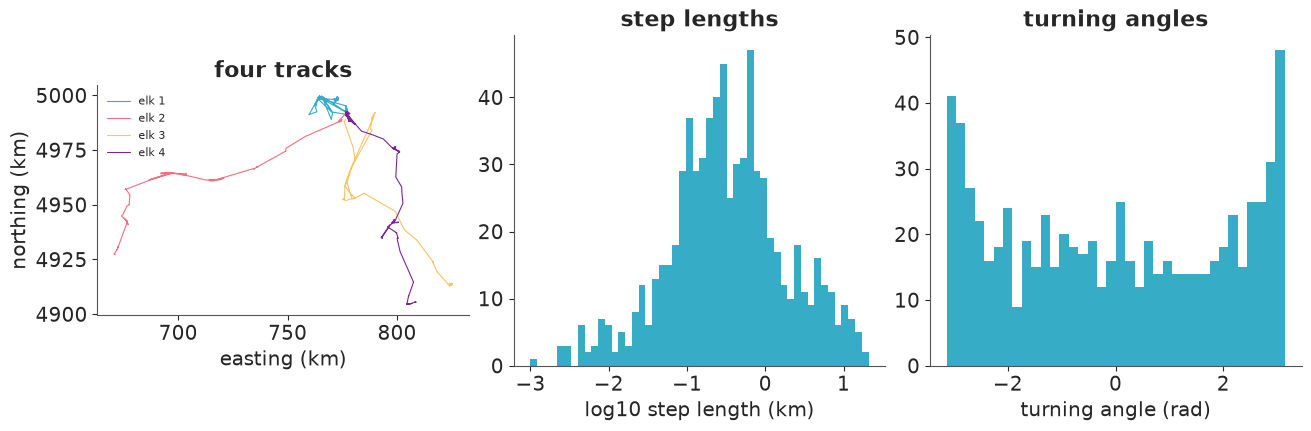

In [21]:
fig = plt.figure(figsize=(13, 4.2))
ax_map = fig.add_subplot(1, 3, 1)
for i, (animal, g) in enumerate(moves.groupby("animal")):
    ax_map.plot(g.x, g.y, "-", lw=0.8, color=f"C{i}", label=f"elk {animal}")
ax_map.set(aspect="equal", xlabel="easting (km)", ylabel="northing (km)", title="four tracks")
ax_map.legend(fontsize=8)
ax = fig.add_subplot(1, 3, 2)
ax.hist(np.log10(moves.step[moves.step > 0]), bins=50, color="C0")
ax.set(xlabel="log10 step length (km)", title="step lengths")
ax = fig.add_subplot(1, 3, 3)
ax.hist(moves.angle.dropna(), bins=36, color="C0")
ax.set(xlabel="turning angle (rad)", title="turning angles");

Step lengths span four orders of magnitude, from metres to 20 km; the histogram on the log
scale has a main hump near 0.3 km and a long right shoulder. The turning angles are
concentrated near $\pm\pi$ (reversals) more than near 0 - the signature of an animal that
goes back and forth within a patch.

One step is exactly zero. A Gamma density cannot take a zero (`moveHMM` adds a zero-mass
parameter for this); for one step out of 731 we simply treat that step length as missing,
which the forward algorithm handles for free, as explained next.

## 9 · The model: two emissions, four sequences, one scan

In state $k$, step length $\sim \text{Gamma}(\text{mean } \mu_k, \text{sd } \mu_k c_k)$ and
turning angle $\sim \text{von Mises}(m_k, \kappa_k)$, independent given the state. Three
implementation details, each a single line:

- **Several sequences** are a batch axis in the scan: emissions are an array
  (time, animal, state), padded to the longest track.
- **Missing values and padding** get a log-emission of **0** (probability 1). In the forward
  recursion that means "no information at this step": the state still evolves through
  $\Gamma$, and since each row of $\Gamma$ sums to 1, padding at the *end* of a track leaves
  its likelihood unchanged. The same zero handles the missing first angle and the zero step.
- **Circular mean without a wrapped parameter.** A free mean angle $m_k \in (-\pi, \pi]$ is the
  wrapped-phase trap of E10 (r_hat ~ 2 at zero divergences). The von Mises log-density
  $\kappa \cos(\theta - m) - \log(2\pi I_0(\kappa))$ equals
  $a\cos\theta + b\sin\theta - \log(2\pi I_0(\sqrt{a^2+b^2}))$ with $a = \kappa\cos m$,
  $b = \kappa\sin m$: Normal priors on $(a, b)$ and no wrapping anywhere.

Priors: mean steps with prior means 0.3 and 3 km, ordered (this is the label-switching fix of
section 3: state 0 is the one with shorter steps); a coefficient of variation with prior mean
1; $(a_k, b_k) \sim$ Normal(0, 1), which allows anything from uniform angles to moderately
concentrated ones; the same Dirichlet rows for $\Gamma$ as in Part A; one shared $\delta$ for
the four first states.

In [22]:
N, T_max = len(animals), moves.groupby("animal").size().max()


def padded(column):
    """(time, animal) array, NaN after the end of each track."""
    out = np.full((T_max, N), np.nan)
    for j, a in enumerate(animals):
        v = moves.loc[moves.animal == a, column].to_numpy()
        out[: len(v), j] = v
    return out


STEP, ANGLE, WATER = padded("step"), padded("angle"), padded("water")
STEP[STEP == 0] = np.nan                         # the single zero step: treated as missing
has_step, has_angle = ~np.isnan(STEP), ~np.isnan(ANGLE)
step_filled, angle_filled = np.where(has_step, STEP, 1.0), np.where(has_angle, ANGLE, 0.0)
water_z = (np.nan_to_num(WATER) - moves.water.mean()) / moves.water.std()  # padding: irrelevant values
print(f"(time, animal) = {STEP.shape}; step lengths used {has_step.sum()}, angles used {has_angle.sum()}")

STATES = ["encamped", "exploring"]


def elk_emissions(mu, cv, ang_cos, ang_sin):
    """log p(step, angle | state): (time, animal, state), 0 where missing or padded."""
    log_step = pm.logp(pm.Gamma.dist(mu=mu, sigma=mu * cv), step_filled[..., None])
    theta = angle_filled[..., None]
    kappa = pt.sqrt(ang_cos**2 + ang_sin**2)
    log_angle = ang_cos * pt.cos(theta) + ang_sin * pt.sin(theta) - pt.log(2 * np.pi * pt.i0(kappa))
    return log_step * has_step[..., None] + log_angle * has_angle[..., None]


def elk_hmm(water_covariate=False):
    coords = {"state": STATES, "to": STATES, "animal": animals}
    with pm.Model(coords=coords) as model:
        mu = pm.Gamma("mu", mu=np.array([0.3, 3.0]), sigma=np.array([0.3, 3.0]), dims="state",
                      transform=pm.distributions.transforms.ordered)
        cv = pm.Gamma("cv", alpha=2, beta=2, dims="state")
        ang_cos = pm.Normal("ang_cos", 0, 1, dims="state")
        ang_sin = pm.Normal("ang_sin", 0, 1, dims="state")
        pm.Deterministic("kappa", pt.sqrt(ang_cos**2 + ang_sin**2), dims="state")
        pm.Deterministic("mean_angle", pt.arctan2(ang_sin, ang_cos), dims="state")
        delta = pm.Dirichlet("delta", a=np.ones(2), dims="state")
        log_emis = elk_emissions(mu, cv, ang_cos, ang_sin)
        if not water_covariate:
            Gamma = pm.Dirichlet("Gamma", a=np.ones((2, 2)) + 4 * np.eye(2), dims=("state", "to"))
            loglik = hmm_loglik(log_emis, pt.log(Gamma), pt.log(delta))
        else:
            # logit P(leave state k) = b0_k + b1_k * standardised distance to water, per step
            b0 = pm.Normal("b0", -1.5, 1.5, dims="state")
            b1 = pm.Normal("b1", 0, 1, dims="state")
            eta = b0 + b1 * water_z[:-1, :, None]                    # (time-1, animal, state)
            log_leave, log_stay = -pt.softplus(-eta), -pt.softplus(eta)
            log_Gamma = pt.stack([pt.stack([log_stay[..., 0], log_leave[..., 0]], -1),
                                  pt.stack([log_leave[..., 1], log_stay[..., 1]], -1)], -2)
            loglik = hmm_loglik(log_emis, log_Gamma, pt.log(delta), time_varying=True)
        pm.Potential("hmm_loglik", loglik.sum())  # one term per animal, summed
    return model


INIT_ELK = {"mu": np.array([0.3, 3.0])}
elk_idata = fit(elk_hmm(), "elk, 2 states", initvals=INIT_ELK)
az.summary(elk_idata, var_names=["mu", "cv", "kappa", "mean_angle", "Gamma"], ci_kind="hdi", ci_prob=0.94, round_to=2)

(time, animal) = (217, 4); step lengths used 730, angles used 727


elk, 2 states: 6 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 1414


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[encamped],0.38,0.03,0.32,0.43,3601.27,2920.30,1.0,0.00,0.00
mu[exploring],3.39,0.52,2.56,4.36,1610.81,1508.07,1.0,0.02,0.02
cv[encamped],1.07,0.04,0.99,1.14,4144.32,3291.30,1.0,0.00,0.00
cv[exploring],1.33,0.11,1.14,1.54,1414.40,943.12,1.0,0.00,0.01
kappa[encamped],0.60,0.08,0.45,0.74,4466.63,3163.49,1.0,0.00,0.00
kappa[exploring],0.26,0.13,0.05,0.50,2628.57,2207.50,1.0,0.00,0.00
mean_angle[encamped],-2.12,2.11,-3.14,3.11,3151.55,3623.73,1.0,0.04,0.04
mean_angle[exploring],0.06,0.70,-1.23,1.38,4660.28,3290.14,1.0,0.01,0.01
"Gamma[encamped, encamped]",0.90,0.02,0.86,0.94,2961.56,2592.83,1.0,0.00,0.00
"Gamma[encamped, exploring]",0.10,0.02,0.06,0.14,2961.56,2592.83,1.0,0.00,0.00


Clean diagnostics. Two clearly separated behaviours:

- **encamped**: mean step about 0.38 km, turning angles centred on $\pm\pi$ (reversals) with
  concentration about 0.6;
- **exploring**: mean step about 3.4 km, turning angles centred near 0 (keep going) but only
  weakly concentrated.

Encamped spells are persistent (stay probability about 0.90), exploring spells shorter (about
0.77). In both states the step lengths are very variable (coefficient of variation above 1),
which is typical of GPS steps between irregular behaviours.

Look at the `mean_angle` row for the encamped state: mean $-2.1$, sd $2.1$, interval from
$-3.14$ to $3.11$. That is not uncertainty, it is **wrapping**: the draws cluster around
$+\pi$ and $-\pi$, which are the same direction, and a linear mean and sd of such draws are
meaningless. This is why the model samples the quadratures $(a, b)$ instead - their summaries
(`ang_cos` about $-0.6$, `ang_sin` about 0) are clean. Summarise circular quantities on the
circle, e.g. by $\operatorname{arctan2}$ of the *mean* quadratures.

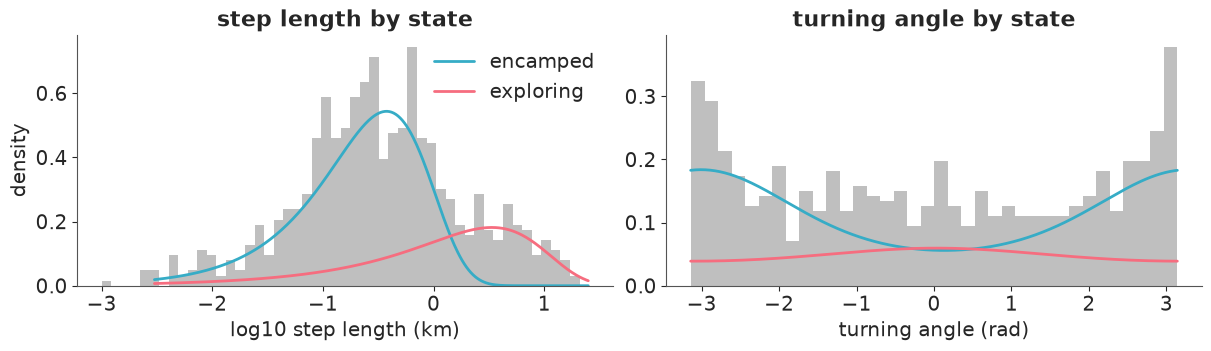

In [23]:
e_mu, e_cv, e_ac, e_as, e_delta = (draws(elk_idata, v, thin=4) for v in ["mu", "cv", "ang_cos", "ang_sin", "delta"])
e_G = draws(elk_idata, "Gamma", thin=4)
S_e = len(e_mu)


def elk_log_emissions_np(mu, cv, ac, as_):
    """NumPy version of elk_emissions for every draw: (S, time, animal, state)."""
    shape, scale = 1 / cv**2, mu * cv**2
    log_step = stats.gamma.logpdf(step_filled[None, ..., None], shape[:, None, None, :], scale=scale[:, None, None, :])
    th = angle_filled[None, ..., None]
    kappa = np.hypot(ac, as_)[:, None, None, :]
    log_angle = (ac[:, None, None, :] * np.cos(th) + as_[:, None, None, :] * np.sin(th)
                 - np.log(2 * np.pi * np.i0(kappa)))
    return log_step * has_step[None, ..., None] + log_angle * has_angle[None, ..., None]


e_log_emis = elk_log_emissions_np(e_mu, e_cv, e_ac, e_as)
e_log_G = np.broadcast_to(np.log(e_G)[:, None, None], (S_e, T_max - 1, N, 2, 2))
e_log_delta = np.log(e_delta)[:, None, :]
e_log_a, e_log_b = forward_backward(e_log_emis, e_log_G, e_log_delta)
e_log_lik = logsumexp(e_log_a[:, -1], axis=-1)  # (S, animal)
p_explore = np.exp(e_log_a + e_log_b - e_log_lik[:, None, :, None])[..., 1].mean(0)  # (time, animal)
e_paths = viterbi(e_log_emis, e_log_G, e_log_delta)  # (S, time, animal)
pi_elk = stationary(e_G)

# state-dependent densities, weighted by the long-run share of each state
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
grid = np.geomspace(0.003, 25, 400)
axes[0].hist(np.log10(moves.step[moves.step > 0]), bins=50, density=True, color="grey", alpha=0.5)
for k in range(2):
    dens = stats.gamma.pdf(grid[:, None], 1 / e_cv[:, k]**2, scale=e_mu[:, k] * e_cv[:, k]**2)
    dens = (dens * pi_elk[:, k]).mean(1) * grid * np.log(10)  # density of log10(step)
    axes[0].plot(np.log10(grid), dens, color=f"C{k}", lw=2, label=STATES[k])
axes[0].set(xlabel="log10 step length (km)", ylabel="density", title="step length by state")
axes[0].legend()
th = np.linspace(-np.pi, np.pi, 200)
axes[1].hist(moves.angle.dropna(), bins=36, density=True, color="grey", alpha=0.5)
for k in range(2):
    kap = np.hypot(e_ac[:, k], e_as[:, k])
    dens = np.exp(e_ac[:, k] * np.cos(th[:, None]) + e_as[:, k] * np.sin(th[:, None])) / (2 * np.pi * np.i0(kap))
    axes[1].plot(th, (dens * pi_elk[:, k]).mean(1), color=f"C{k}", lw=2, label=STATES[k])
axes[1].set(xlabel="turning angle (rad)", title="turning angle by state");

Each curve is the state's density times its long-run share, averaged over posterior draws,
so the two curves add up to the model's marginal distribution. The encamped state covers the
main hump and the reversals; the exploring state is the shoulder of long steps, with nearly
uniform turning angles. The two step densities cross at about 1.4 km and overlap over roughly
0.3-3 km: a single step in that range is ambiguous, and its state is decided by its neighbours.

Now the states on the map, and along one track in time:

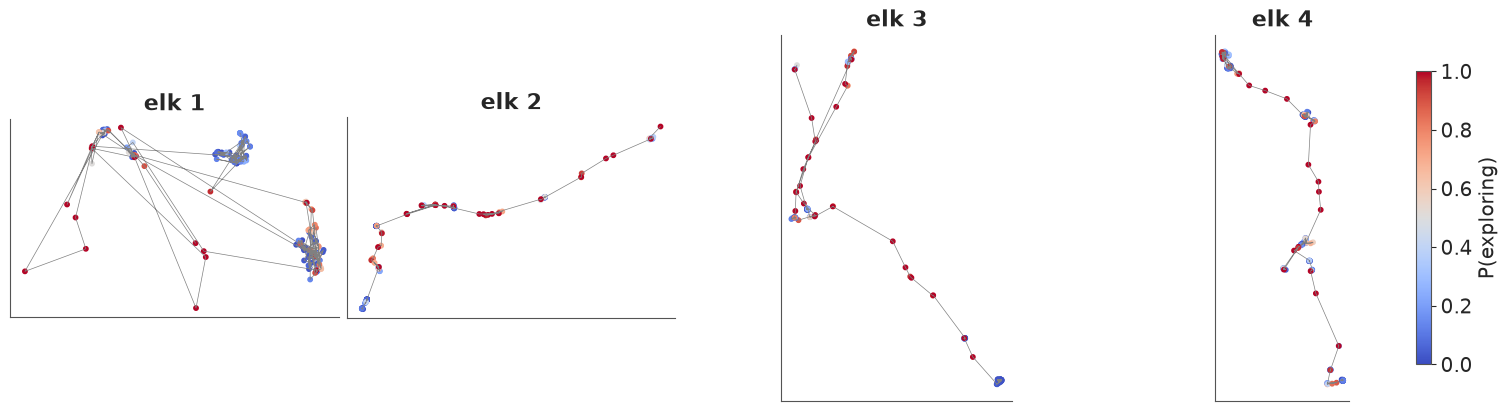

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for j, (ax, a) in enumerate(zip(axes, animals)):
    g = moves[moves.animal == a]
    n = len(g)
    ax.plot(g.x, g.y, "-", color="grey", lw=0.5)
    sc = ax.scatter(g.x, g.y, c=p_explore[:n, j], cmap="coolwarm", vmin=0, vmax=1, s=10)
    ax.set(aspect="equal", title=f"elk {a}", xticks=[], yticks=[])
fig.colorbar(sc, ax=axes, label="P(exploring)", shrink=0.8);

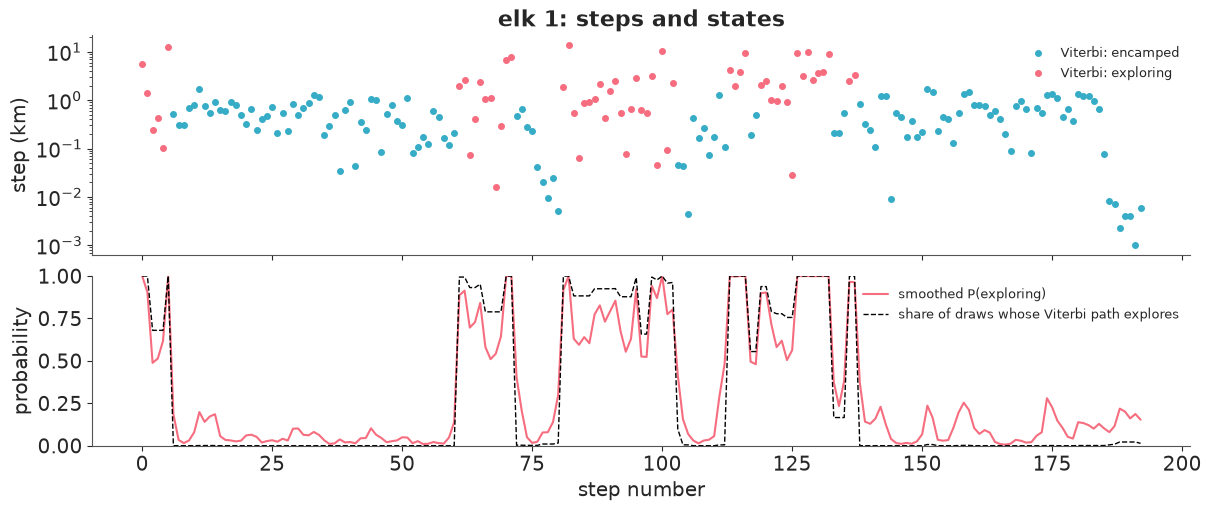

In [25]:
j = 0
g = moves[moves.animal == animals[j]]
n = len(g)
map_path = viterbi(e_log_emis[:, :n, j:j + 1].mean(0, keepdims=True),
                   np.log(e_G.mean(0))[None, None, None].repeat(n - 1, 1), np.log(e_delta.mean(0))[None, None])[0, :, 0]
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, height_ratios=[1.3, 1])
for k in range(2):
    sel = map_path == k
    axes[0].plot(np.arange(n)[sel], g.step.to_numpy()[sel], "o", ms=4, color=f"C{k}", label=f"Viterbi: {STATES[k]}")
axes[0].set(yscale="log", ylabel="step (km)", title=f"elk {animals[j]}: steps and states")
axes[0].legend(fontsize=9)
axes[1].plot(np.arange(n), p_explore[:n, j], color="C1", lw=1.5, label="smoothed P(exploring)")
axes[1].plot(np.arange(n), (e_paths[:, :n, j] == 1).mean(0), color="k", lw=1, ls="--",
             label="share of draws whose Viterbi path explores")
axes[1].set(xlabel="step number", ylabel="probability", ylim=(0, 1))
axes[1].legend(fontsize=9);

Exploring bouts are the long straight runs between patches on the map; the tight clusters are
encamped. Along elk 1's track (Viterbi path at the posterior-mean parameters in the top panel)
long encamped spells alternate with exploring bouts. The smoothed probability is near 0 in
the encamped spells but only 0.5-0.8 through much of the stretch between steps 80 and 100,
where medium steps of 0.5-2 km follow each other; the per-draw Viterbi paths (dashed) call
most of that stretch "exploring" with near certainty. The two summaries answer different
questions, and neither is an observation: "the" state sequence is a summary of a posterior.
(The last few steps of the track are a few metres long - probably GPS noise around a resting
animal - and firmly encamped.)

## 10 · Checks: pseudo-residuals for steps, dwell times

Step lengths are continuous, so the forecast pseudo-residual is simply
$\Phi^{-1}(F_t(\text{step}_t))$, with $F_t$ the one-step-ahead mixture of the two Gamma CDFs.

step pseudo-residuals: mean -0.01, sd 0.99, Shapiro-Wilk p = 0.04


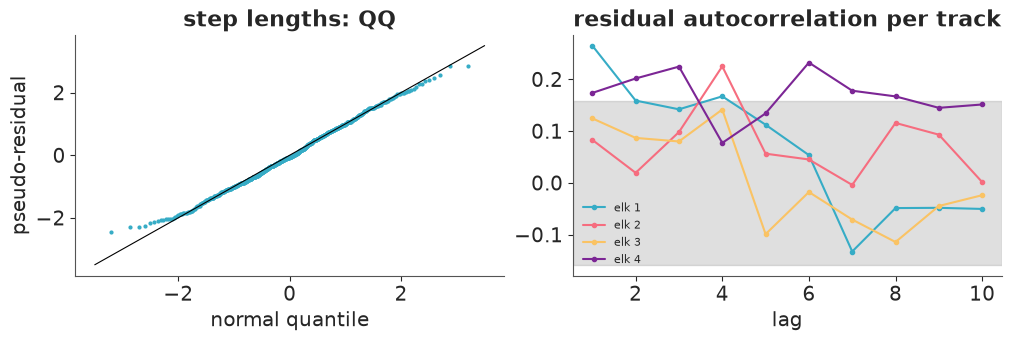

In [26]:
e_pred = predicted_state_logprob(e_log_a, e_log_G, e_log_delta)
e_w = np.exp(e_pred - logsumexp(e_pred, axis=-1, keepdims=True))  # (S, time, animal, state)


def step_pseudo_residuals(weights, mu, cv):
    cdf = stats.gamma.cdf(step_filled[None, ..., None], 1 / cv[:, None, None, :]**2,
                          scale=(mu * cv**2)[:, None, None, :])
    u = (weights * cdf).sum(-1).mean(0)  # posterior predictive CDF at the observed step
    return np.where(has_step, stats.norm.ppf(np.clip(u, 1e-12, 1 - 1e-12)), np.nan)


z_elk = step_pseudo_residuals(e_w, e_mu, e_cv)
zz = z_elk[has_step]
print(f"step pseudo-residuals: mean {zz.mean():.2f}, sd {zz.std():.2f}, "
      f"Shapiro-Wilk p = {stats.shapiro(zz).pvalue:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
q = stats.norm.ppf((np.arange(len(zz)) + 0.5) / len(zz))
axes[0].plot(q, np.sort(zz), "o", ms=2)
axes[0].plot([-3.5, 3.5], [-3.5, 3.5], color="k", lw=0.8)
axes[0].set(xlabel="normal quantile", ylabel="pseudo-residual", title="step lengths: QQ")
ac_by_animal = np.array([acf(z_elk[has_step[:, j], j], 10)[1:] for j in range(N)])
for j in range(N):
    axes[1].plot(np.arange(1, 11), ac_by_animal[j], "o-", ms=3, color=f"C{j}", label=f"elk {animals[j]}")
axes[1].axhspan(-2 / np.sqrt(160), 2 / np.sqrt(160), color="grey", alpha=0.25)
axes[1].set(xlabel="lag", title="residual autocorrelation per track")
axes[1].legend(fontsize=8);

The QQ plot follows the diagonal except in the lower tail, where the observed residuals are
*less* extreme than normal ones (the model gives the very shortest steps a little too much
probability; Shapiro-Wilk p about 0.04). The autocorrelation panel is the more important
finding: for elk 4 the residual autocorrelation is positive at every lag and mostly above the
white-noise band (drawn for a typical track length of 160), and elk 1 has a lag-1 value above
it too. Two states capture most, but not all, of the serial dependence in step lengths:
there is slower variation within the "encamped" state, for instance, that a third state or
animal-specific parameters could pick up (Try it yourself 1). A check on angles would use
the circular analogue; we skip it.

In [27]:
e_dwell = 1 / (1 - np.diagonal(e_G, axis1=1, axis2=2))
for k in range(2):
    print(f"{STATES[k]:9s}: long-run share {pi_elk[:, k].mean():.2f}, dwell time {e_dwell[:, k].mean():.1f} steps "
          f"(94% HDI {az.hdi(e_dwell[:, k], prob=0.94).round(1)})")
print("initial-state probabilities delta:", e_delta.mean(0).round(2), "(prior mean 0.5, 4 tracks)")

encamped : long-run share 0.69, dwell time 11.0 steps (94% HDI [ 6.4 15.9])
exploring: long-run share 0.31, dwell time 4.9 steps (94% HDI [2.  7.7])
initial-state probabilities delta: [0.37 0.63] (prior mean 0.5, 4 tracks)


An encamped spell lasts about ten relocations on average, an exploring bout about four or
five; elk spend roughly 70% of their time encamped. $\delta$ is informed by four first steps
only. A common alternative is to set $\delta$ to the stationary distribution of $\Gamma$
("the tracks start at a random time"), which removes a parameter and is right for tracks that
do not start at a special moment - but these elk were *released*, and a released animal may
well begin by exploring, so here a free $\delta$ is the more honest choice.

## 11 · Covariate-dependent transitions: does water matter?

Morales et al. asked whether the switching depends on the habitat. The natural extension
gives each step its own transition matrix, with

$$
\text{logit}\, P(\text{leave state } k \text{ at step } t) = b_{0k} + b_{1k}\, \text{water}_t,
$$

where $\text{water}_t$ is the standardised distance to water at the start of the step. The
scan takes the $(T-1)$ matrices as a *sequence* instead of a constant - the
`time_varying=True` branch of `hmm_loglik`, built above as `elk_hmm(water_covariate=True)`.

In [28]:
elk_cov_idata = fit(elk_hmm(water_covariate=True), "elk, 2 states, water-dependent transitions", initvals=INIT_ELK)
az.summary(elk_cov_idata, var_names=["b0", "b1", "mu", "kappa"], ci_kind="hdi", ci_prob=0.94, round_to=2)

elk, 2 states, water-dependent transitions: 7 s, divergences = 0, max r_hat = 1.00, min ess_bulk = 1057


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[encamped],-2.05,0.26,-2.55,-1.57,2698.03,2990.91,1.0,0.01,0.00
b0[exploring],-0.34,0.49,-1.21,0.63,1327.15,870.97,1.0,0.01,0.01
b1[encamped],-0.42,0.24,-0.88,0.01,3973.57,3004.43,1.0,0.00,0.00
b1[exploring],1.22,0.48,0.33,2.13,4217.33,2687.89,1.0,0.01,0.01
mu[encamped],0.37,0.03,0.31,0.43,2080.23,2443.70,1.0,0.00,0.00
mu[exploring],3.74,0.66,2.73,5.05,1097.53,922.86,1.0,0.02,0.03
kappa[encamped],0.58,0.08,0.44,0.74,3059.72,2776.94,1.0,0.00,0.00
kappa[exploring],0.31,0.14,0.06,0.56,2497.28,2329.55,1.0,0.00,0.00


slopes b1 (per sd of distance = 0.79 km): {'encamped': '-0.41 [-0.88, -0.01]', 'exploring': '1.22 [0.38, 2.11]'}


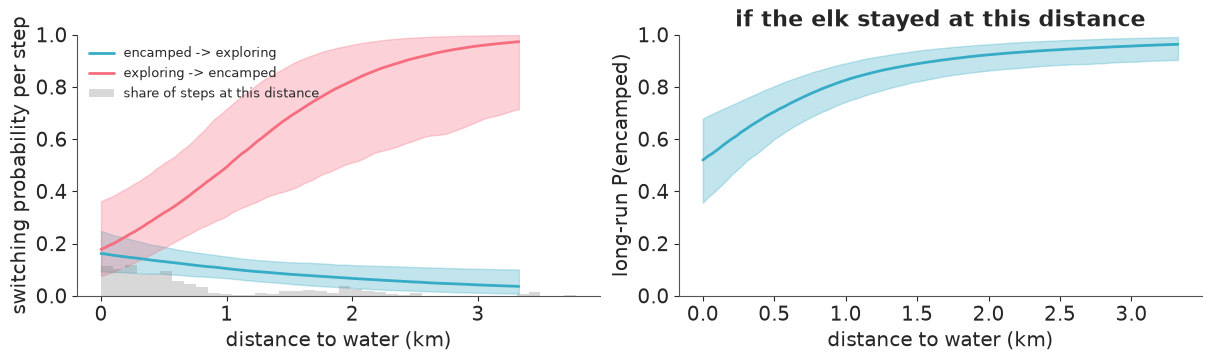

In [29]:
b0, b1 = draws(elk_cov_idata, "b0", thin=4), draws(elk_cov_idata, "b1", thin=4)
water_km = np.linspace(0, moves.water.quantile(0.98), 100)
wz = (water_km - moves.water.mean()) / moves.water.std()
p_leave = expit(b0[:, None, :] + b1[:, None, :] * wz[None, :, None])  # (S, grid, state)
G_grid = np.stack([np.stack([1 - p_leave[..., 0], p_leave[..., 0]], -1),
                   np.stack([p_leave[..., 1], 1 - p_leave[..., 1]], -1)], -2)
pi_grid = stationary(G_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for k, label in enumerate(["encamped -> exploring", "exploring -> encamped"]):
    lo, hi = np.quantile(p_leave[..., k], [0.05, 0.95], axis=0)
    axes[0].fill_between(water_km, lo, hi, color=f"C{k}", alpha=0.3)
    axes[0].plot(water_km, np.median(p_leave[..., k], 0), color=f"C{k}", lw=2, label=label)
axes[0].set(xlabel="distance to water (km)", ylabel="switching probability per step", ylim=(0, 1))
axes[0].hist(moves.water, bins=40, weights=np.full(len(moves), 1 / len(moves)), color="grey", alpha=0.3,
             label="share of steps at this distance")
axes[0].legend(loc="upper left", fontsize=9)
lo, hi = np.quantile(pi_grid[..., 0], [0.05, 0.95], axis=0)
axes[1].fill_between(water_km, lo, hi, color="C0", alpha=0.3)
axes[1].plot(water_km, np.median(pi_grid[..., 0], 0), color="C0", lw=2)
axes[1].set(xlabel="distance to water (km)", ylabel="long-run P(encamped)",
            title="if the elk stayed at this distance", ylim=(0, 1))
print("slopes b1 (per sd of distance =", round(moves.water.std(), 2), "km):",
      {s: f"{m:.2f} [{lo_:.2f}, {hi_:.2f}]" for s, m, lo_, hi_ in zip(
          STATES, b1.mean(0), *np.quantile(b1, [0.03, 0.97], axis=0))})

The farther from water, the *more* likely an exploring elk is to settle (the slope's 94%
interval is well away from zero), and - less certainly - the less likely an encamped elk is to
set off (that slope's interval just reaches zero). In long-run terms, if an elk stayed at a
given distance, it would be encamped about half of the time right next to water and over 90%
of the time 2 km or more away: elk travel near water and settle away from it. The bands are
wide beyond about 1.5 km because few steps start there (grey histogram: most start within
about 1 km of water). The step and angle parameters barely change - the covariate only
redistributes *when* switches happen.

Does it improve prediction? The integrated LOO carries over unchanged to time-varying $\Gamma$
(one term per step; pointwise over all 4 tracks).

In [30]:
c_mu, c_cv, c_ac, c_as, c_delta = (draws(elk_cov_idata, v, thin=4) for v in ["mu", "cv", "ang_cos", "ang_sin", "delta"])
c_log_emis = elk_log_emissions_np(c_mu, c_cv, c_ac, c_as)
eta = b0[:, None, None, :] + b1[:, None, None, :] * water_z[None, :-1, :, None]
lp_leave, lp_stay = -np.logaddexp(0, -eta), -np.logaddexp(0, eta)
c_log_G = np.stack([np.stack([lp_stay[..., 0], lp_leave[..., 0]], -1),
                    np.stack([lp_leave[..., 1], lp_stay[..., 1]], -1)], -2)
c_log_a, c_log_b = forward_backward(c_log_emis, c_log_G, np.log(c_delta)[:, None, :])

observed = (has_step | has_angle)
elk_loos = {}
for name, idata, (la, lb, lG, ld) in [
    ("constant transitions", elk_idata, (e_log_a, e_log_b, e_log_G, e_log_delta)),
    ("water-dependent", elk_cov_idata, (c_log_a, c_log_b, c_log_G, np.log(c_delta)[:, None, :])),
]:
    ll = loo_integrated(la, lb, lG, ld)[:, observed]  # (S, observed steps)
    thinned = idata.isel(draw=slice(None, None, 4))
    elk_loos[name] = az.loo(with_log_lik(thinned, ll, dim="step", coord=np.arange(ll.shape[1])))
    print(f"{name:21s} max Pareto k = {float(elk_loos[name].pareto_k.max()):.2f}")
az.compare(elk_loos, round_to=1)

constant transitions  max Pareto k = 0.54


water-dependent       max Pareto k = 0.50


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
water-dependent,0,0.0,0.0,NaN,,,17.2,-1880.9,47.5,0.7
constant transitions,1,-2.0,3.9,0.7,|elpd_diff| < 4,,14.9,-1882.9,47.1,0.3


The covariate model is ahead by about two units of elpd, with a difference standard error of
about four: no demonstrable gain in predicting individual steps. That is not a contradiction
of the slopes. LOO scores step lengths and angles, and those are dominated by the emission
densities; the covariate only changes the (already uncertain) timing of the few dozen
switches, and most steps start where the two transition models differ little. A covariate
can be clearly "there" in the parameters and still be worth little for prediction. (Ideally one would also leave out *whole
tracks* to ask whether the effect generalises to a new animal; with four animals that is four
refits, each ~20 s - try it.)

## 12 · Summary

| Step | What we did |
|---|---|
| Likelihood | forward algorithm, `pytensor.scan` + `logsumexp`, as a `pm.Potential`; checked against `pymc_extras` (`DiscreteMarkovChain` + `marginalize`) to six decimals |
| Identification | ordered state means (or step means); the unordered version gives r_hat 1.3-1.5 |
| States | forward-backward smoothing and Viterbi per posterior draw in NumPy; `recover` for sampled paths |
| Persistence | stationary distribution and dwell times as posteriors - and their prior sensitivity |
| Checks | forecast (mid-)pseudo-residuals and their autocorrelation; replicated dispersion and autocorrelation |
| How many states | 3 states on weak data: divergences and merged states; integrated LOO and leave-future-out |
| Extensions | several sequences via padding, missing data as log-emission 0, circular means via quadratures, covariate-dependent $\Gamma$ |

**Limits.** The states are a modelling device: "busy regime" and "encamped" are labels for
mixture components with Markov dynamics, and they absorb any misspecification (a trend, a
catalogue change, a change of GPS schedule) as if it were a state. Dwell times are geometric
by assumption; hidden *semi*-Markov models relax that at a cost of a larger state space. And
the forward algorithm is exact but sequential: every gradient runs the scan over the whole
series, so cost grows linearly with its length (and with $K^2$) - fine for hundreds of steps,
as here, a consideration for tens of thousands.

## Try it yourself

1. **Three behavioural states.** Fit the elk model with $K = 3$ (ordered step means, e.g.
   prior means 0.1, 0.5 and 3 km). Is the third state distinct, or do you get the section-7
   symptoms? Compare with the integrated LOO, and look at the step pseudo-residuals again.
2. **Leave one track out.** For the elk, refit four times, each time without one animal, and
   score the left-out track with `hmm_loglik` (its whole-sequence log-likelihood, averaged
   over the posterior with log-mean-exp). Does the water covariate help for a *new* animal?
3. **The textbook series.** Restrict the earthquake catalogue to magnitude 6.8+ (a threshold
   that gives a mean close to the book's) or to 1900-2006 and refit K = 1, 2, 3. Does the
   evidence for regimes come back? Be careful: at lower thresholds the early catalogue is
   incomplete, and a trend in completeness looks exactly like a regime.